In [3]:
%load_ext autoreload
%autoreload 2
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.constants import year

from src import file_io as fio

In [4]:
# chandra low high table
raw_chandra = [
    ["pha_a", 3.00, 30.00],
    ["pha_b", 3.00, 45.00],
    ["pha_c", 16.07, 166.70],
    ["pha_d", 20.00, 225.00],
    ["pha_e", 20.00, 225.00]
]
factor_chandra = pd.DataFrame(data=raw_chandra, columns=["detector", 0, 1])
factor_chandra.set_index("detector", inplace=True)

# magic number in chandra paper pha = tlm/1023 * factor
magic_chandra = 1023

In [5]:
#quick test
factor_chandra.loc["pha_c", 0]

np.float64(16.07)

In [6]:
def calc_de_dx(row):
    return row["pha_a"] / magic_chandra * factor_chandra.loc["pha_a", row["a_lh_flag"]]

def calc_total_energy(row):
    apply_factors =  row["pha_a"] * factor_chandra.loc["pha_a", row["a_lh_flag"]] + \
                     row["pha_b"] * factor_chandra.loc["pha_b", row["b_lh_flag"]] + \
                     row["pha_c"] * factor_chandra.loc["pha_c", row["c_lh_flag"]] + \
                     row["pha_d"] * factor_chandra.loc["pha_d", row["d_lh_flag"]] + \
                     row["pha_e"] * factor_chandra.loc["pha_e", row["e_lh_flag"]]
    return apply_factors / magic_chandra

In [7]:
path = fio.get_data_files("phx", "2003", "1")[0]
df = fio.read_pha(path)

df["de/dx"] = df.apply(calc_de_dx, axis=1)
df["total_energy"] = df.apply(calc_total_energy, axis=1)

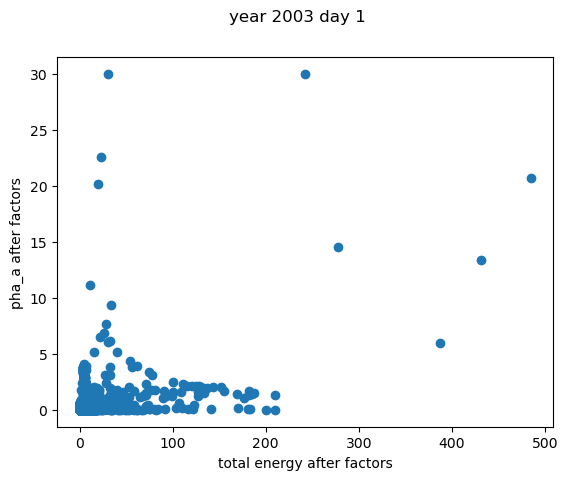

In [8]:
fig, ax = plt.subplots()
ax.set_xlabel("total energy after factors")
ax.set_ylabel("pha_a after factors")
ax.scatter(df["total_energy"], df["de/dx"])
fig.suptitle("year 2003 day 1")
plt.show()

In [13]:
# now do it again for all of 2003
files_2003 = fio.get_data_files("phx", "2003")
accum = pd.concat([fio.read_pha(f) for f in files_2003])
accum["de/dx"] = df.apply(calc_de_dx, axis=1)
accum["total_energy"] = df.apply(calc_total_energy, axis=1)


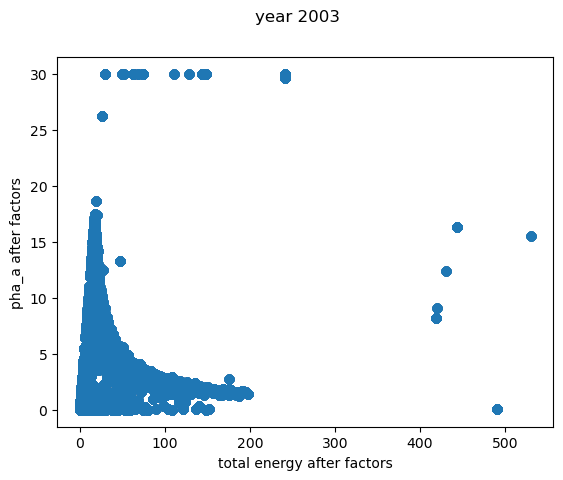

In [14]:
fig, ax = plt.subplots()
ax.set_xlabel("total energy after factors")
ax.set_ylabel("pha_a after factors")
ax.scatter(accum["total_energy"], accum["de/dx"])
fig.suptitle("year 2003")
plt.show()